<a href="https://colab.research.google.com/github/dionatrafk/model_evaluation/blob/master/ARIMA_exec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auto Regressive Integrated Moving Average (ARIMA)

In [ ]:
#Importar datasets
!git clone https://github.com/dionatrafk/model_evaluation

In [4]:
#define hyperparameters p
hyperparameters = [
('trace1.csv', 0, 1, 2),
('trace5.csv', 2, 0, 1),
('trace10.csv', 0, 1, 1),
('trace15.csv', 0, 2, 1),
('trace20.csv', 1, 0, 2),
('trace25.csv', 4, 0, 1),
('trace30.csv', 2, 0, 2),
('trace35.csv', 4, 0, 1),
('trace40.csv', 8, 0, 1),
('trace45.csv', 2, 0, 2),
('trace50.csv', 2, 0, 1),
('trace55.csv', 10, 0, 2),
('trace60.csv', 2, 1, 2),
]
results = []

In [5]:
from pandas import read_csv
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt
import numpy as np
import math
import datetime

def arima_forecast(fileName, p, d, q):
    path = './http_requests_nasa/'
    filename = path + fileName

    #perc = float(sys.argv[5])
    print(p, d, q)
    #read the csv file
    dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)

    # split into train and test sets
    X = dataset.values
    X = X.astype('float32')
    size = int(len(X) * 0.67)
    train, test = X[0:size], X[size:len(X)]
    series = [x for x in train]
    predictions = list()

    training_size = len(train)

    #test with less samples	
    #size = int(training_size * (perc /100))
    #series = series[size:training_size:]
    timer = start = datetime.datetime.now() 
    # walk-forward validation
    #print 'current, prediction'
    for t in range(len(test)):
        model = ARIMA(series, order=(p, d, q))
        model_fit = model.fit()
        output = model_fit.forecast()

        yhat = output[0]
        predictions.append(yhat)
        current = test[t]
        series.append(current)

        #print('%.2f, %.2f' % (current,yhat))

    # evaluate forecasts

    yhat = np.asarray(predictions, dtype=np.float32)
    y_test = test.flatten()
    print("Timer: ", datetime.datetime.now() - timer)
    mse = mean_squared_error(y_test, yhat)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_test, yhat)
    r2 = r2_score(y_test, yhat)
    print('R2: %.2f, Testscore: %.2f MSE (%.2f RMSE)' %(r2,mse, rmse))

    # plot some samples
    sample_size = min(100, len(y_test))
    plt.figure(figsize=(10, 4))
    plt.plot(yhat[-sample_size:], label='Predicted')
    plt.plot(y_test[-sample_size:], label='Current')
    plt.legend()
    plt.grid(True)
    plt.ylabel('Requests')
    plt.xlabel('Time')
    plt.title(f'ARIMA({p}, {d}, {q}) - {fileName}')
    plt.tight_layout()
    plt.show()
    return {
        "dataset": fileName,
        "p": p,
        "d": d,
        "q": q,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
    }

0 1 2


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  1:55:49.183226
R2: 0.72, Testscore: 196.25 MSE (14.01 RMSE)


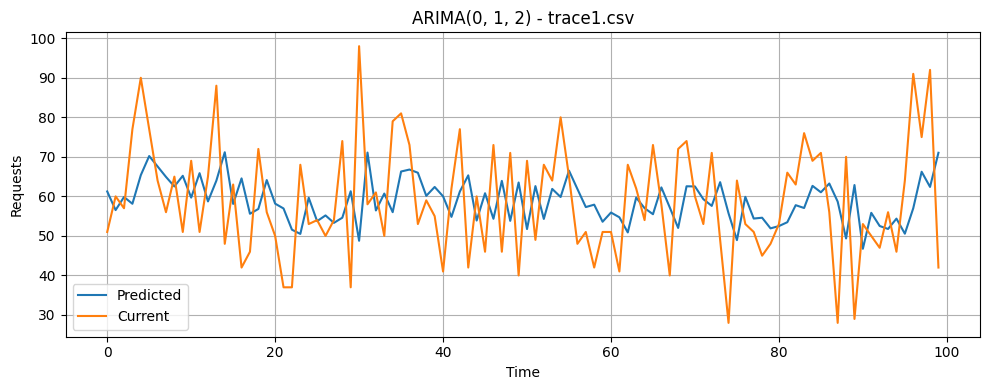

2 0 1


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  0:21:08.650952
R2: 0.84, Testscore: 2290.91 MSE (47.86 RMSE)


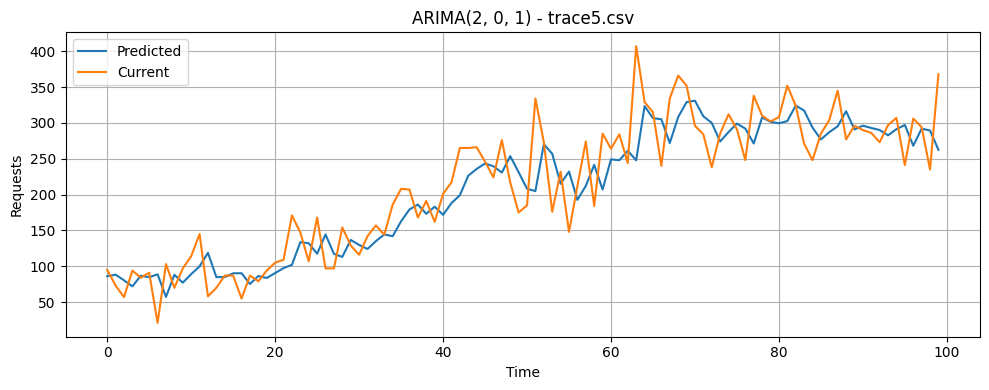

0 1 1


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  0:00:39.487914
R2: 0.86, Testscore: 7563.41 MSE (86.97 RMSE)


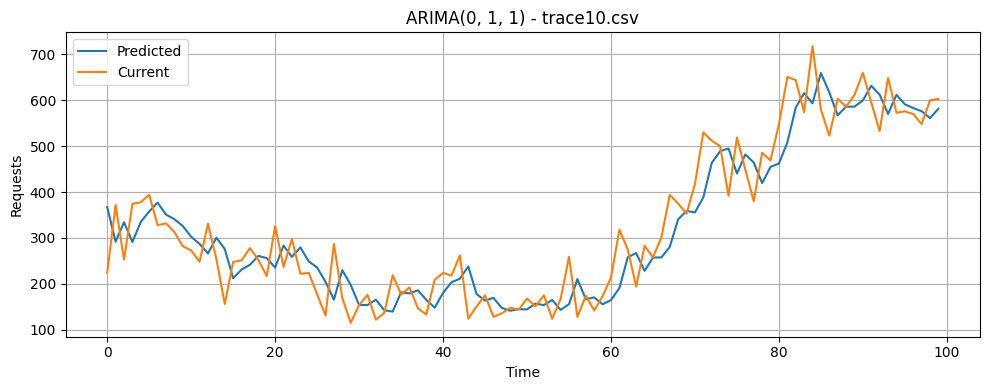

0 2 1


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)
/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Timer:  0:00:48.610708
R2: 0.84, Testscore: 18228.17 MSE (135.01 RMSE)


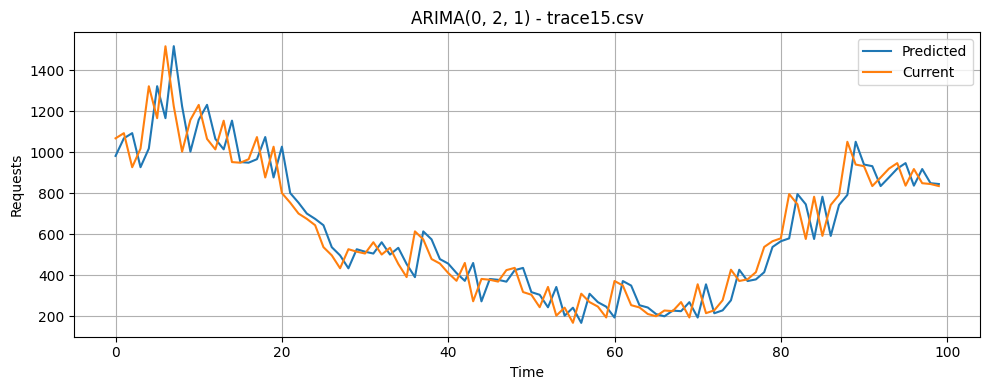

1 0 2


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  0:00:46.155041
R2: 0.86, Testscore: 28349.19 MSE (168.37 RMSE)


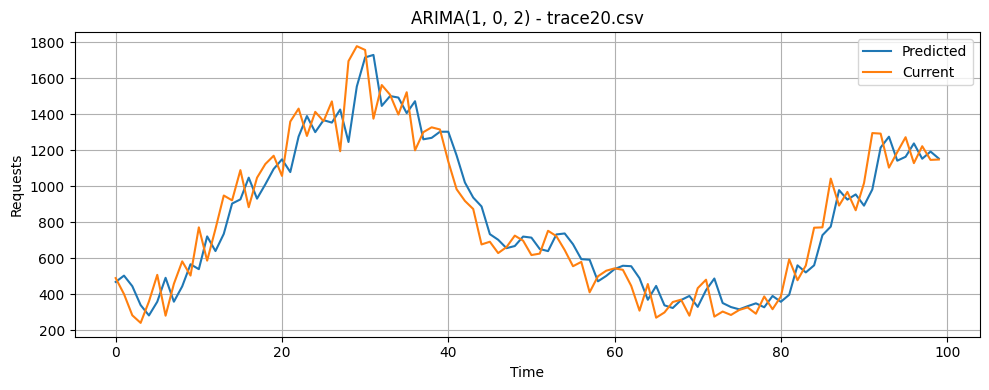

4 0 1


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)
/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabriel.herter/Documents/Personal/faculdade/prti

Timer:  0:02:03.303977
R2: 0.88, Testscore: 36473.24 MSE (190.98 RMSE)


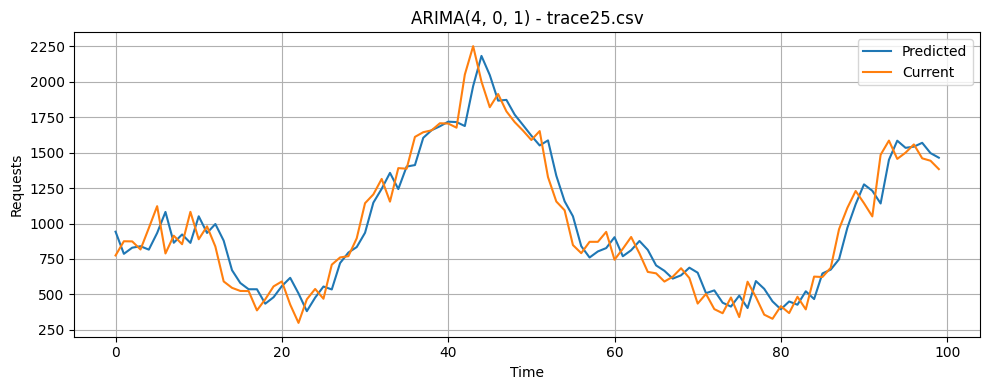

2 0 2


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  0:00:57.422564
R2: 0.87, Testscore: 56478.45 MSE (237.65 RMSE)


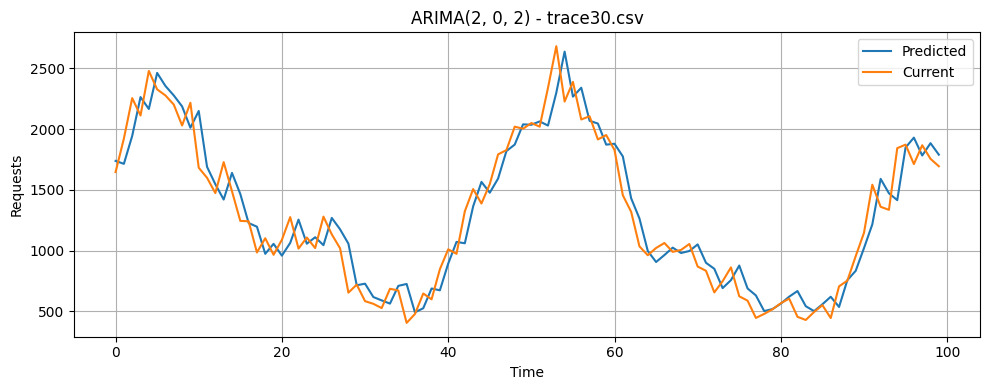

4 0 1


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)
/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabriel.herter/Documents/Personal/faculdade/prti

Timer:  0:00:58.064414
R2: 0.89, Testscore: 69346.09 MSE (263.34 RMSE)


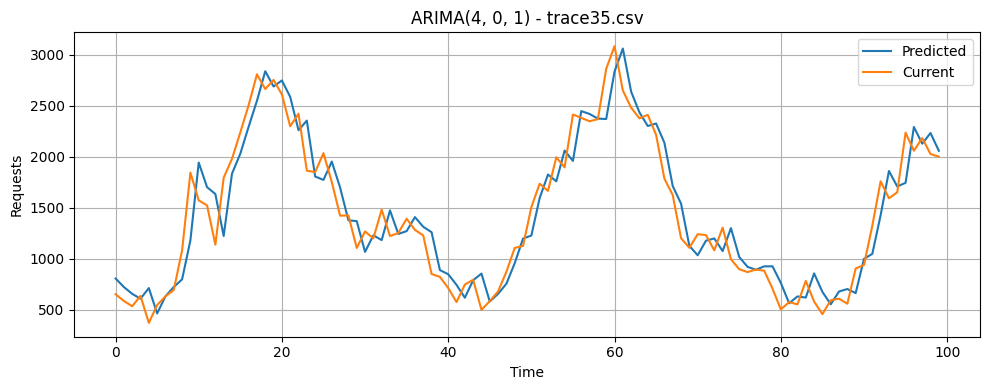

8 0 1


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  0:01:18.000133
R2: 0.87, Testscore: 100172.47 MSE (316.50 RMSE)


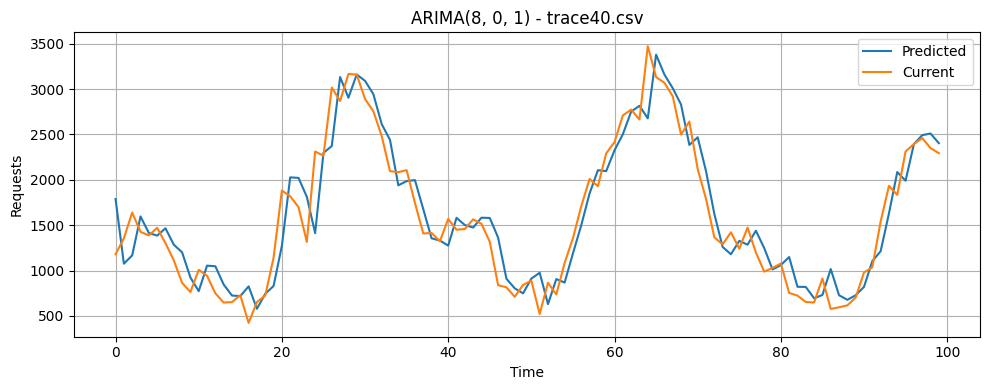

2 0 2


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  0:00:17.816676
R2: 0.87, Testscore: 129869.46 MSE (360.37 RMSE)


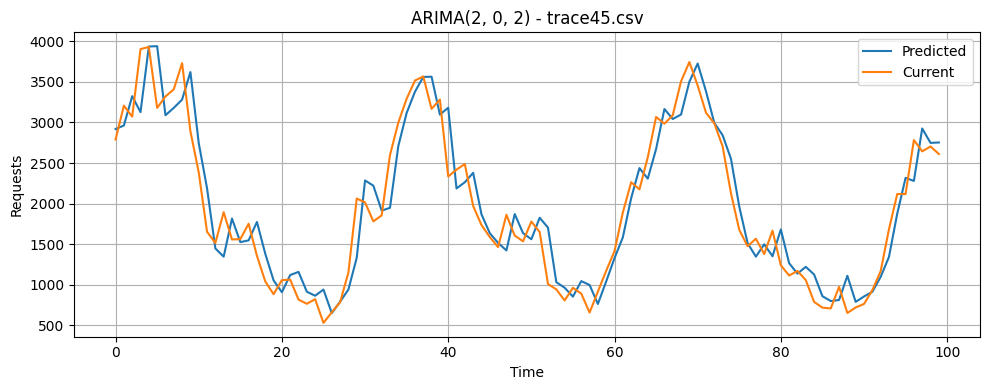

2 0 1


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  0:00:12.969377
R2: 0.88, Testscore: 144388.22 MSE (379.98 RMSE)


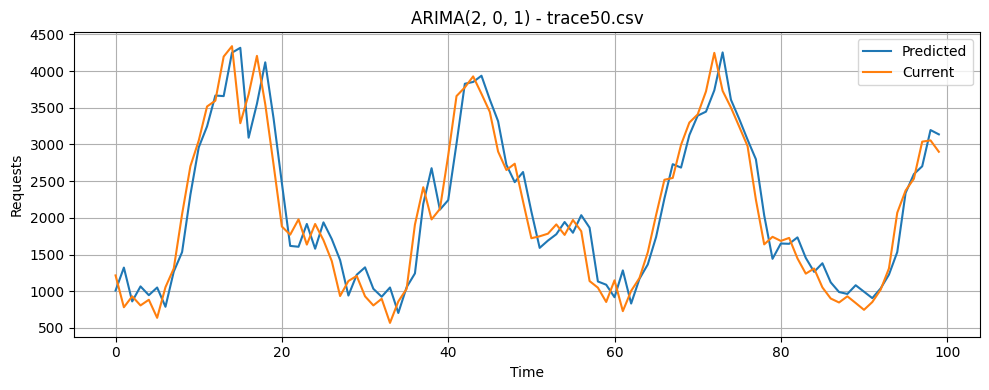

10 0 2


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)
/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabriel.herter/Documents/Personal/faculdade/prti

Timer:  0:01:28.911547
R2: 0.86, Testscore: 198587.45 MSE (445.63 RMSE)


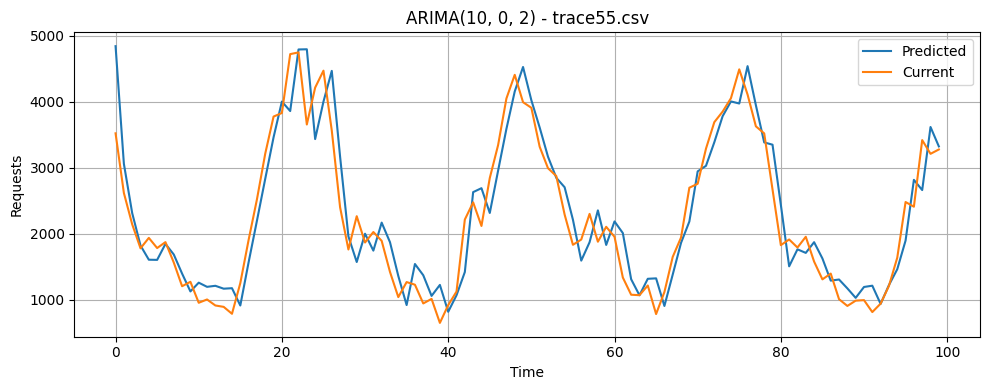

2 1 2


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_4302/1353936648.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  0:00:06.366968
R2: 0.84, Testscore: 276937.16 MSE (526.25 RMSE)


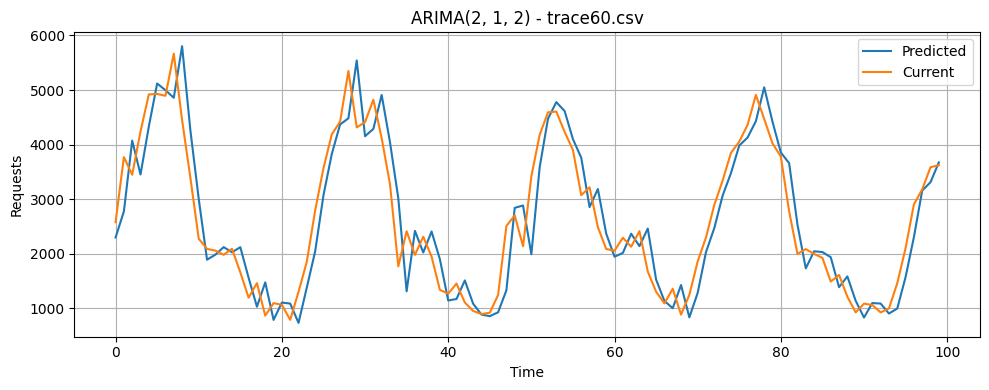

,dataset,p,d,q,mae,mse,rmse,r2
0,trace1.csv,0,1,2,10.624,196.247,14.009,0.7160
1,trace5.csv,2,0,1,36.077,2290.914,47.863,0.8364
2,trace10.csv,0,1,1,64.256,7563.408,86.968,0.8574
3,trace15.csv,0,2,1,101.278,18228.166,135.012,0.8432
4,trace20.csv,1,0,2,127.521,28349.188,168.372,0.8610
5,trace25.csv,4,0,1,146.196,36473.238,190.980,0.8832
6,trace30.csv,2,0,2,175.096,56478.445,237.652,0.8742
7,trace35.csv,4,0,1,202.196,69346.094,263.336,0.8852
8,trace40.csv,8,0,1,238.303,100172.469,316.500,0.8724
9,trace45.csv,2,0,2,274.688,129869.461,360.374,0.8687


In [6]:
import pandas as pd

results = []
for params in hyperparameters:
    filename, p, d, q = params
    result = arima_forecast(filename, p, d, q)
    results.append(result)

if results:
    summary_df = pd.DataFrame(results)
    summary_df = summary_df[["dataset", "p", "d", "q", "mae", "mse", "rmse", "r2"]]
    display(summary_df.round({"mae": 3, "mse": 3, "rmse": 3, "r2": 4}))